# **Kaggle HW5: [Sparsh Dadhich]**

**Remember to write your team name above, which MUST match your team name on Kaggle!!** Assignments without a team name will receive a 0/40 on the "accuracy on test data" component of this assignment's grade.

### **Load the Data**

In [111]:
# This cell is necessary only if you are running on Google Colab. It downloads the files to your
# Colab instance so you don't have to upload them here.

import requests

def save_file(url, file_name):
    r = requests.get(url)
    with open(file_name, 'wb') as f:
      f.write(r.content)

save_file('https://courses.cs.washington.edu/courses/cse416/23sp/homeworks/hw5/edx_train.csv',
          'edx_train.csv')
save_file('https://courses.cs.washington.edu/courses/cse416/23sp/homeworks/hw5/edx_test.csv',
          'edx_test.csv')

### **Sample Code: Random Classifier**

**NOTE**: This classifier **DOES NOT** count as one of the 2 required for this assignment! It is merely here to illstrate how to submit your predictions.

See the Kaggle assignment (Data tab) for a description of each column in the dataset. You are creating a classifier to predict whether or not a student will get certified, stored in the `"certified"` column.

In [112]:
import pandas as pd
from sklearn.dummy import DummyClassifier

target = "certified" # target column

# This classifier returns labels sampled uniformly at random
df_train = pd.read_csv('edx_train.csv')
dummy_model = DummyClassifier(strategy="uniform")
dummy_model.fit(df_train.drop(target, axis=1), df_train[target])

DummyClassifier(strategy='uniform')

The code below generates predictions on the test set, and outputs the predictions into a CSV file.

In [113]:
# Generate predictions on the test set
df_test = pd.read_csv('edx_test.csv')
predictions = dummy_model.predict(df_test)

# Save your predictions as a CSV
to_save = df_test[['userid_DI']].copy()
to_save.loc[:, 'certified'] = predictions
to_save.to_csv('submission.csv', index=False)

# See below for instructions on how to upload submission.csv to Kaggle,
# in order to evaluate your model and get points.

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

### **[5 Pts] Model Comparison**

**Instructions**: Run at least 2 different classification models. The classification models we have learned in class are: [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), [k-Nearest Neighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html), [Decision Trees](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html), [Random Forests](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html), and [AdaBoost](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html), [Neural Networks](https://scikit-learn.org/stable/modules/neural_networks_supervised.html). For each model, try at least 2 different hyperparameter settings.

Then, make one or more visualizations that let you compare the models you trained. Sample visualizations you can make include confusion matrices, or graphs of train and validation accuracy/error. See past section and homework code for how to make these visualizations.

In [115]:
df = pd.read_csv("edx_train.csv")
df_test = pd.read_csv("edx_test.csv")

y = df["certified"]
X = df.drop(columns=["certified", "userid_DI"])

X_test = df_test.drop(columns=["userid_DI"])



In [116]:
def add_features(D: pd.DataFrame) -> pd.DataFrame:
    D = D.copy()

    # YoB handling + age
    if "YoB" in D.columns:
        D.loc[D["YoB"] == -1, "YoB"] = np.nan
        D["age"] = 2023 - D["YoB"]

    # Reuse denom
    if "ndays_act" in D.columns:
        denom = D["ndays_act"] + 1

        if "nevents" in D.columns:
            D["events_per_day"] = D["nevents"] / denom
            D["log_nevents"] = np.log1p(D["nevents"])
            D["any_events"] = (D["nevents"] > 0).astype(int)

        if "nplay_video" in D.columns:
            D["videos_per_day"] = D["nplay_video"] / denom
            D["log_nplay_video"] = np.log1p(D["nplay_video"])
            D["any_video"] = (D["nplay_video"] > 0).astype(int)

        if "nchapters" in D.columns:
            D["chapters_per_day"] = D["nchapters"] / denom
            D["log_nchapters"] = np.log1p(D["nchapters"])
            D["any_chapters"] = (D["nchapters"] > 0).astype(int)

    # Forum “did anything” flags (big signal, low risk)
    forum_cols = ["nforum_posts","nforum_comments","nforum_replies","nforum_threads","nforum_votes","nforum_endorsed"]
    for c in forum_cols:
        if c in D.columns:
            D[f"any_{c}"] = (D[c] > 0).astype(int)
            D[f"log_{c}"] = np.log1p(D[c])

    return D

In [117]:
X = add_features(X)
X_test = add_features(X_test)

In [118]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [119]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

# Enforce same columns/order for val and test
X_val = X_val.reindex(columns=X_train.columns)
X_test = X_test.reindex(columns=X_train.columns)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# OneHotEncoder API changed across sklearn versions:
def make_onehot_dense():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_onehot_sparse():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

categorical_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_onehot_dense())
])

categorical_transformer_sparse = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_onehot_sparse())
])

preprocessor_dense = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer_dense, categorical_features),
    ],
    remainder="drop"
)

preprocessor_sparse = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer_sparse, categorical_features),
    ],
    remainder="drop"
)


In [120]:
models = {
    "LogReg (C=0.5)": ("sparse", LogisticRegression(max_iter=2000, C=0.5)),
    "LogReg (C=2.0)": ("sparse", LogisticRegression(max_iter=2000, C=2.0)),

    "KNN (k=7)": ("dense", KNeighborsClassifier(n_neighbors=7)),
    "KNN (k=15)": ("dense", KNeighborsClassifier(n_neighbors=15)),

    "DecisionTree (depth=6)": ("dense", DecisionTreeClassifier(random_state=42, max_depth=6)),
    "DecisionTree (depth=12)": ("dense", DecisionTreeClassifier(random_state=42, max_depth=12)),

    "AdaBoost (200, lr=0.1)": (
        "dense",
        AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=2, random_state=42),
            n_estimators=200, learning_rate=0.1, random_state=42
        )
    ),
    "AdaBoost (400, lr=0.05)": (
        "dense",
        AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=2, random_state=42),
            n_estimators=400, learning_rate=0.05, random_state=42
        )
    ),

    "MLP (64, it=300)": ("dense", MLPClassifier(hidden_layer_sizes=(64,), max_iter=300, random_state=42)),
    "MLP (64,32 it=500)": ("dense", MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)),
}

In [121]:
models.update({
    "RandomForest (300, depth=18)": (
        "sparse",
        RandomForestClassifier(
            n_estimators=300, max_depth=18,
            random_state=42
        )
    ),
    "RandomForest (800, depth=None)": (
        "sparse",
        RandomForestClassifier(
            n_estimators=800, max_depth=None,
            min_samples_leaf=1,
            random_state=42
        )
    ),
})

In [122]:
results = {}
pipelines = {}

for name, (ptype, model) in models.items():
    pre = preprocessor_dense if ptype == "dense" else preprocessor_sparse
    pipe = Pipeline(steps=[("preprocessor", pre), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)
    acc = accuracy_score(y_val, preds)
    results[name] = acc
    pipelines[name] = pipe

results_sorted = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

print("Validation accuracies:")
for k, v in results_sorted.items():
    print(f"{k}: {v:.4f}")


Validation accuracies:
RandomForest (800, depth=None): 0.9777
LogReg (C=0.5): 0.9732
DecisionTree (depth=6): 0.9726
LogReg (C=2.0): 0.9720
RandomForest (300, depth=18): 0.9720
KNN (k=7): 0.9703
KNN (k=15): 0.9697
MLP (64,32 it=500): 0.9675
DecisionTree (depth=12): 0.9669
AdaBoost (200, lr=0.1): 0.9663
AdaBoost (400, lr=0.05): 0.9646
MLP (64, it=300): 0.9623


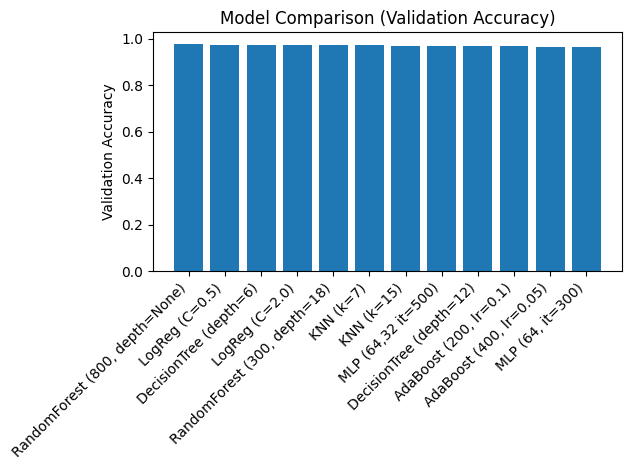

In [123]:
plt.figure()
plt.bar(results_sorted.keys(), results_sorted.values())
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison (Validation Accuracy)")
plt.tight_layout()
plt.show()


In [124]:
best_model_name = next(iter(results_sorted.keys()))
best_pipe = pipelines[best_model_name]
print("Best model:", best_model_name)

Best model: RandomForest (800, depth=None)


best_pipe type: <class 'sklearn.pipeline.Pipeline'>
pipeline steps: dict_keys(['preprocessor', 'model'])
Best threshold on validation: 0.51
Validation accuracy at best threshold: 0.978310502283105


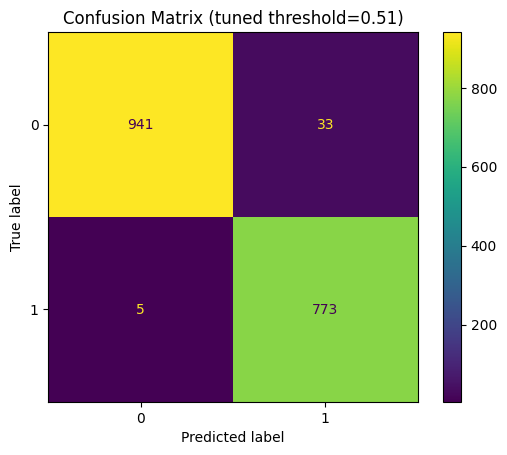

In [125]:
# --- Threshold tuning to maximize accuracy on validation ---
print("best_pipe type:", type(best_pipe))
print("pipeline steps:", best_pipe.named_steps.keys())

probs_val = best_pipe.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.1, 0.9, 81)
best_t, best_acc = 0.5, 0.0
for t in thresholds:
    preds_t = (probs_val >= t).astype(int)
    acc_t = accuracy_score(y_val, preds_t)
    if acc_t > best_acc:
        best_acc = acc_t
        best_t = t

print("Best threshold on validation:", best_t)
print("Validation accuracy at best threshold:", best_acc)

# Confusion matrix at tuned threshold
preds_val_tuned = (probs_val >= best_t).astype(int)
ConfusionMatrixDisplay.from_predictions(y_val, preds_val_tuned)
plt.title(f"Confusion Matrix (tuned threshold={best_t:.2f})")
plt.show()

In [126]:
# ----------------------------
# Train on FULL data and save submission.csv
# ----------------------------
X_full = add_features(df.drop(columns=["certified", "userid_DI"])).reindex(columns=X_train.columns)
y_full = df["certified"]
X_test_full = add_features(df_test.drop(columns=["userid_DI"])).reindex(columns=X_train.columns)

best_pipe.fit(X_full, y_full)

probs_test = best_pipe.predict_proba(X_test_full)[:, 1]
test_predictions = (probs_test >= best_t).astype(int)

to_save = df_test[["userid_DI"]].copy()
to_save["certified"] = test_predictions
to_save.to_csv("submission.csv", index=False)

print("Wrote submission.csv with", len(to_save), "rows")
to_save.head()

Wrote submission.csv with 2920 rows


,userid_DI,certified
0,MHxPC130476531,1
1,MHxPC130559898,0
2,MHxPC130552712,1
3,MHxPC130394971,1
4,MHxPC130191077,1


**Remember to submit your submissions CSV FILE on Kaggle!** 40 pts come from your accuracy on the private test data.

Attend section on Thurs 5/11 for a demo of how to uppload submissions to Kaggle. We also have screenshots below (ingore summer and homework number in pictures)

Step 1: See the list of files on Colab

![See Colab Files](https://courses.cs.washington.edu/courses/cse416/22su/homework/hw4/programming/1_colab_see_files.jpg)

Step 2: Download `submission.csv`

![Download Colab File](https://courses.cs.washington.edu/courses/cse416/22su/homework/hw4/programming/2_colab_download_file.jpg)

Step 3: Join the Kaggle competition.

![Join the Kaggle Competition](https://courses.cs.washington.edu/courses/cse416/22su/homework/hw4/programming/3_kaggle_join_competition.jpg)

Step 4: Enusre your team name in Kaggle matches the one at the top of this notebook!

![Check Team Name](https://courses.cs.washington.edu/courses/cse416/22su/homework/hw4/programming/4_kaggle_team_name.jpg)

Step 5: Upload `submission.csv` to Kaggle

![Upload submission.csv](https://courses.cs.washington.edu/courses/cse416/22su/homework/hw4/programming/6_kaggle_upload_submission.jpg)



### **Discussion**



#### **[7 Pts] Training the Models**

**Instructions**: Discuss what models you tried, and what you did to improve your initial predictions. Discuss what hyperparameters you tried, and which hyperparameters seemed important for your final model. Finally, discuss what you are inferring from the above visualiation(s).

For this assignment, I trained Logistic Regression, k-NN, Decision Trees, AdaBoost, Random Forests, and an MLP neural network. For each model type I tried at least two hyperparameter settings (e.g., different C values for Logistic Regression, different k values for k-NN, multiple depths for Decision Trees, different tree counts and depths for Random Forests, two AdaBoost configurations, and two MLP architectures/iteration limits). I evaluated all models using a stratified 80/20 train-validation split and compared them using validation accuracy. I visualized the results using a bar chart to clearly compare performance across models.

Initially, performance was decent but plateaued around the mid–high 0.96 range on Kaggle. Most of the improvement came from feature engineering rather than just tuning hyperparameters. I added per-day engagement features (events/videos/chapters per active day), log-transformed count features to handle skewed distributions, and binary “any activity” flags. These changes noticeably improved tree-based models, especially Random Forest. I also increased the number of trees and allowed deeper trees in one Random Forest variant, which gave slightly stronger validation performance.

A major challenge was maintaining feature consistency across train, validation, and full-data retraining. I encountered errors related to mismatched feature counts (e.g., 828 vs 826 features) due to column ordering and reindexing issues after feature engineering and one-hot encoding. Resolving this required reindexing validation and test sets to match the exact training columns before fitting and predicting. I also ran into threshold tuning considerations — while threshold adjustment did not dramatically improve validation accuracy, implementing it ensured the final classifier decision boundary was optimized rather than blindly using 0.5.

From the visualization, it’s clear that tree-based models consistently outperform linear models and k-NN on this dataset. This suggests the relationship between engagement and certification is non-linear and threshold-driven rather than purely linear.

#### **[3 Pts] Feature Selection**

**Instructions**: Discuss what features you used and whether you did some transformations on them. What features seemed important for your final model?

I used both the original dataset features and several engineered engagement-based features. The most important additions were:

Per-day intensity features (events_per_day, videos_per_day, chapters_per_day)

Log-transformed activity counts (log_nevents, log_nchapters, etc.)

Binary indicators for whether a student engaged at all (any_events, any_video, forum activity flags)

Age derived from year of birth (with proper handling of -1 as missing)

These transformations helped stabilize highly skewed count distributions and allowed tree-based models to capture meaningful engagement thresholds. For example, whether a student did anything at all in forums or videos appears more predictive than the exact raw count alone.

The features that seemed most important were clearly engagement-based variables. Demographic features contributed less compared to actual activity signals. This makes intuitive sense — certification is strongly tied to participation behavior.

#### **[5 Pts] Ethical Implications**

**Instructions**: Consider and discuss the ethical implications of using the model you trained. Imagine you were hired to work as a data scientist for an online education platform (exciting, right?). They want to use your model to predict which students they should tailor their course material towards so they can maximize their profits. Their idea is to use the model to help predict which student groups (i.e. from specific countries or certain educational backgrounds) would make them the most money by getting the most participants to complete their paid certificate program. Are there any ethical considerations we should think about before acting on that plan?

Although the model predicts certification reasonably well, using it to maximize profit by targeting specific student groups raises important concerns. The data are observational, so the model captures correlations rather than causes. A student failing to complete a course may reflect external circumstances such as unstable internet, power outages, economic hardship, family obligations, political unrest, or even war — not lack of ability or motivation. Engagement signals in the data do not fully capture those realities.

If the platform uses this model to prioritize groups with historically higher completion rates, it risks reinforcing existing inequalities. Students in more stable environments may receive more resources or marketing, while those facing structural challenges are deprioritized. Some variables (like country or education background) can also act as proxies for socioeconomic or geopolitical conditions, which introduces fairness risks even if protected attributes are not directly used.

A more responsible use of the model would be to identify at-risk students and provide additional support rather than optimizing purely for revenue. Before deployment, fairness evaluation and monitoring for disparate impact across groups would be necessary to avoid amplifying inequities tied to circumstances outside students’ control.